<a href="https://colab.research.google.com/github/darrickpang/Email/blob/master/Trajectory_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install nuscenes-devkit torch numpy matplotlib tqdm

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from nuscenes.nuscenes import NuScenes

DATA_ROOT = "/content/drive/MyDrive/v1.0-mini"  # adjust if local
nusc = NuScenes(version='v1.0-mini', dataroot=DATA_ROOT, verbose=True)

print("Number of scenes:", len(nusc.scene))

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 5.054 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.
Number of scenes: 10


In [ ]:
def get_vehicle_trajectory(nusc, instance_token):
    positions = []

    for ann in nusc.sample_annotation:
        if ann["instance_token"] == instance_token:
            x, y, _ = ann["translation"]
            positions.append((ann["timestamp"], x, y))

    positions.sort(key=lambda x: x[0])
    return positions

In [ ]:
scene = nusc.scene[0]   # first scene in mini
print(scene["name"])

scene-0061


In [ ]:
sample_token = scene["first_sample_token"]
sample = nusc.get("sample", sample_token)

In [ ]:
vehicle_ann = None

for ann_token in sample["anns"]:
    ann = nusc.get("sample_annotation", ann_token)
    if ann["category_name"].startswith("vehicle"):
        vehicle_ann = ann
        break

vehicle_ann

{'token': '924ee6ac1fed440a9d9e3720aac635a0',
 'sample_token': 'ca9a282c9e77460f8360f564131a8af5',
 'instance_token': 'bd26c2cdb22d4bb1834e808c89128898',
 'visibility_token': '3',
 'attribute_tokens': ['c3246a1e22a14fcb878aa61e69ae3329'],
 'translation': [353.794, 1132.355, 0.602],
 'size': [2.011, 4.633, 1.573],
 'rotation': [0.9797276292877292, 0.0, 0.0, -0.20033415188191459],
 'prev': '',
 'next': 'f0cbd9dbafd74e20bcf6dd0357c97f59',
 'num_lidar_pts': 5,
 'num_radar_pts': 0,
 'category_name': 'vehicle.car'}

In [ ]:
instance_token = vehicle_ann["instance_token"]
print(instance_token)

bd26c2cdb22d4bb1834e808c89128898


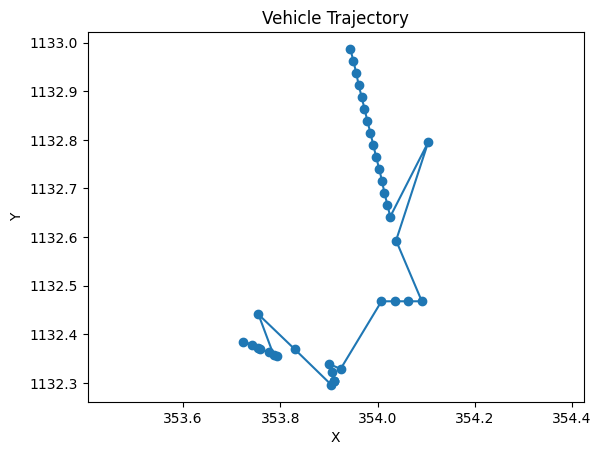

In [ ]:
import matplotlib.pyplot as plt

# Redefine the function with the fix
def get_vehicle_trajectory(nusc, instance_token):
    positions = []

    for ann_data in nusc.sample_annotation:
        if ann_data["instance_token"] == instance_token:
            x, y, _ = ann_data["translation"]
            # Get the sample related to this annotation to retrieve the timestamp
            sample_record = nusc.get('sample', ann_data['sample_token'])
            timestamp = sample_record['timestamp']
            positions.append((timestamp, x, y))

    positions.sort(key=lambda x: x[0])
    return positions

traj = get_vehicle_trajectory(nusc, instance_token)

xs = [p[1] for p in traj]
ys = [p[2] for p in traj]

plt.plot(xs, ys, marker="o")
plt.title("Vehicle Trajectory")
plt.xlabel("X")
plt.ylabel("Y")
plt.axis("equal")
plt.show()

In [ ]:
traj_lengths = []

for inst in vehicle_instances:
    traj = get_vehicle_trajectory(nusc, inst["token"])
    traj_lengths.append(len(traj))

import numpy as np
print("Min:", np.min(traj_lengths))
print("Mean:", np.mean(traj_lengths))
print("Max:", np.max(traj_lengths))

Min: 1
Mean: 20.26890756302521
Max: 41


In [ ]:
import numpy as

# From above, we see that the max is 41 frames so we don't wantto have 0 length for len(all_samples)
PAST_LEN = 8     # 0.8 seconds
FUTURE_LEN = 12   # 1.2 seconds

def create_trajectory_samples(traj):
    """
    traj: list of (timestamp, x, y)
    returns: list of (past, future)
    """
    samples = []
    traj = sorted(traj, key=lambda x: x[0])

    coords = np.array([[p[1], p[2]] for p in traj])

    for i in range(len(coords) - PAST_LEN - FUTURE_LEN):
        past = coords[i : i + PAST_LEN]
        future = coords[i + PAST_LEN : i + PAST_LEN + FUTURE_LEN]
        samples.append((past, future))

    return samples

In [ ]:
vehicle_instances = []

for inst in nusc.instance:
    category = nusc.get("category", inst["category_token"])
    if category["name"].startswith("vehicle"):
        vehicle_instances.append(inst)

len(vehicle_instances)

476

In [ ]:
all_samples = []

for inst in vehicle_instances:
    traj = get_vehicle_trajectory(nusc, inst["token"])

    # 🚨 Filter short tracks
    if len(traj) < PAST_LEN + FUTURE_LEN:
        continue

    samples = create_trajectory_samples(traj)
    all_samples.extend(samples)

len(all_samples)

2532

In [ ]:
def normalize(past, future):
    origin = past[-1]
    return past - origin, future - origin

In [ ]:
import torch
from torch.utils.data import Dataset

class TrajectoryDataset(Dataset):
    def __init__(self, samples):
        self.data = []
        for past, future in samples:
            p, f = normalize(past, future)
            self.data.append((p, f))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        past, future = self.data[idx]
        return (
            torch.tensor(past, dtype=torch.float32),
            torch.tensor(future, dtype=torch.float32)
        )

In [ ]:
from torch.utils.data import DataLoader

dataset = TrajectoryDataset(all_samples)
loader = DataLoader(dataset, batch_size=64, shuffle=True)